# Garbage classification
[Source]("https://www.kaggle.com/code/adenarayana/garbage-classification-pytorch"])

## 0. Setup

In [2]:
# Imports
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
from torchinfo import summary

# Input file preparation
from pathlib import Path
import random
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [3]:
# Image file path
image_path = Path(
    "../data/garbage-classification/Garbage classification/Garbage classification"
)

image_path

WindowsPath('../data/garbage-classification/Garbage classification/Garbage classification')

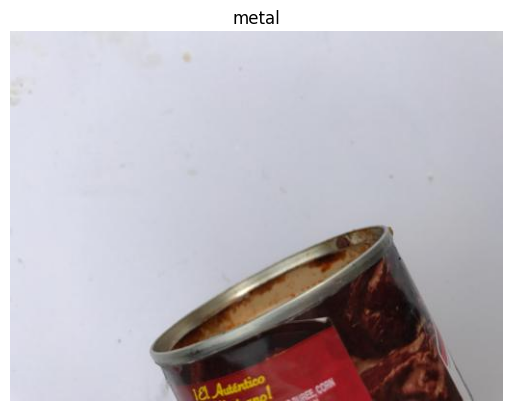

In [4]:
# create a list of all image files
image_path_list = list(image_path.glob("*/*.jpg"))

# select a random image (directory)
random_image_path = random.choice(image_path_list)

# plot the selected image
img_random = plt.imread(random_image_path)
plt.imshow(img_random)
plt.title(random_image_path.parent.stem)  # title is the folder name
plt.axis("off")
plt.show()

## 1. Data preprocessing

In [5]:
# get the trained model parameters
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

# create data transformation based on the pretrained model
data_transform = weights.transforms()

print(data_transform)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [6]:
# create dataset using ImageFolder function from torchvision
img_dataset = datasets.ImageFolder(root=image_path, transform=data_transform)

print(img_dataset)

Dataset ImageFolder
    Number of datapoints: 2527
    Root location: ..\data\garbage-classification\Garbage classification\Garbage classification
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )


In [7]:
# we can use the image dataset to create a list of class names (garbage type)
class_names = img_dataset.classes
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [8]:
def get_class_names():
    return class_names

In [9]:
# set the training and testing data size
train_size, test_size = 0.7, 0.3

# split the dataset into training anda testing dataset
train_data, test_data = random_split(img_dataset, [train_size, test_size])

len(train_data), len(test_data)

(1769, 758)

In [10]:
# training dataloader
train_dataloader = DataLoader(
    dataset=train_data, batch_size=32, num_workers=2, shuffle=True
)

# testing dataloader
test_dataloader = DataLoader(
    dataset=test_data, batch_size=32, num_workers=2, shuffle=False
)

print(len(train_dataloader))
print(len(test_dataloader))

56
24


In [11]:
train_image_batch, train_label_batch = next(iter(train_dataloader))

train_image_batch.shape, train_label_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.343704].


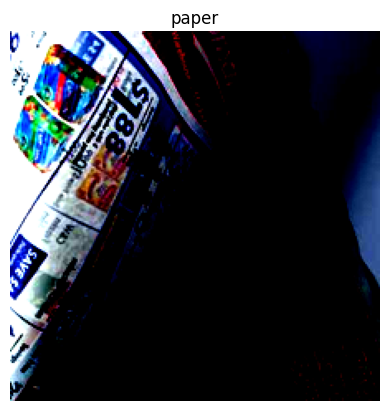

In [12]:
img_batch = train_image_batch[0, :, :, :]
img_batch_label = class_names[train_label_batch[0]]

plt.imshow(img_batch.permute(1, 2, 0))
plt.title(img_batch_label)
plt.axis("off")
plt.show()

## 3. Model setup

In [13]:
# download the pretrained EfficientNet model
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [14]:
summary(
    model=model,
    input_size=(32, 3, 224, 224),  # (batch_size, channels, height, width)
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [15]:
# first, freeze the model parameter in "features" layer
for param in model.features.parameters():
    param.requires_grad = False

# determine the output shape based on the total number of class
output_shape = len(class_names)

# redifine the "classifier" layer
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(
        in_features=1280,
        out_features=output_shape,  # we only change this part
        bias=True,
    ),
).to(device)

# preview the model architecture after we modify the "classifier" layer
summary(
    model=model,
    input_size=(32, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 6]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

## 4. Model training

In [16]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
epochs = 20 # optimal for the test loss

train_loss_holder = []
test_loss_holder = []

for epoch in range(epochs):
    print(f"Epoch: {epoch}\n------------------")

    train_loss = 0

    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)

        model.train()

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)

    with torch.inference_mode():
        test_loss = 0

        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)

            model.eval()

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)

        test_loss /= len(test_dataloader)

    print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}\n")
    train_loss_holder.append(train_loss.detach().cpu().numpy())
    test_loss_holder.append(test_loss.detach().cpu().numpy())

Epoch: 0
------------------
Train loss: 1.27199 | Test loss: 0.93624

Epoch: 1
------------------
Train loss: 0.83313 | Test loss: 0.75542

Epoch: 2
------------------
Train loss: 0.69950 | Test loss: 0.68194

Epoch: 3
------------------
Train loss: 0.62257 | Test loss: 0.63117

Epoch: 4
------------------
Train loss: 0.58134 | Test loss: 0.60442

Epoch: 5
------------------
Train loss: 0.54446 | Test loss: 0.59139

Epoch: 6
------------------
Train loss: 0.50457 | Test loss: 0.56080

Epoch: 7
------------------
Train loss: 0.47274 | Test loss: 0.54143

Epoch: 8
------------------
Train loss: 0.45601 | Test loss: 0.52940

Epoch: 9
------------------
Train loss: 0.45142 | Test loss: 0.52452

Epoch: 10
------------------
Train loss: 0.43839 | Test loss: 0.51567

Epoch: 11
------------------
Train loss: 0.40735 | Test loss: 0.51475

Epoch: 12
------------------
Train loss: 0.39807 | Test loss: 0.51138

Epoch: 13
------------------
Train loss: 0.38517 | Test loss: 0.49663

Epoch: 14
------

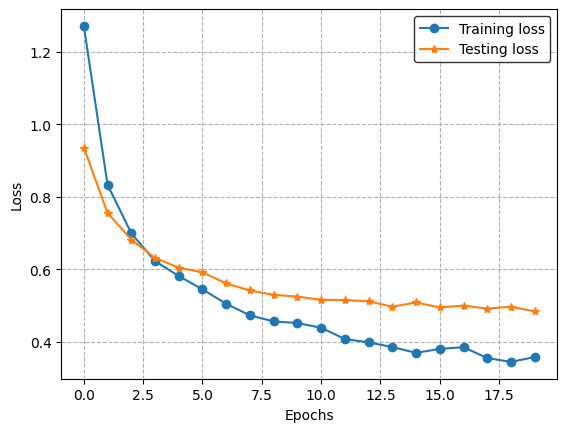

In [20]:
epoch_total = range(epochs)
fig, ax = plt.subplots()
ax.plot(epoch_total, train_loss_holder, "-o", label="Training loss")
ax.plot(epoch_total, test_loss_holder, "-*", label="Testing loss")
ax.grid(ls='--')
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.legend(edgecolor="black")
plt.show()

In [21]:
# Saving the trained model
torch.save(model, "garbage_classification_model.pth")